In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. 載入資料(正規化處理)


---

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata, pearsonr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import KNNImputer

# 路徑設定
PATH = '/content/drive/MyDrive/Kidney_Methylation/'

def load_methyl(cg_path, eg_path):
    df_cg = pd.read_csv(cg_path, index_col=0).T
    df_eg = pd.read_csv(eg_path, index_col=0).T
    df_cg.columns = df_cg.columns.str.lower()
    df_eg.columns = df_eg.columns.str.lower()
    common = df_cg.columns.intersection(df_eg.columns)
    X = pd.concat([df_cg[common], df_eg[common]], axis=0)
    y = np.concatenate([np.zeros(df_cg.shape[0]), np.ones(df_eg.shape[0])])
    # 用KNN補遺漏值
    imputer = KNNImputer(n_neighbors=5)
    X_imputed = imputer.fit_transform(X)

    X_final = pd.DataFrame(X_imputed, index=X.index, columns=X.columns)
    return X_final, y

# 廢案
# def rank_norm(Xdf):
#     """Per-sample rank normalization: removes cohort-level scale offsets."""
#     Xv = Xdf.values.astype(float)
#     out = np.array([rankdata(row) / len(row) for row in Xv])          # r-1 / N-1
#     return pd.DataFrame(out, index=Xdf.index, columns=Xdf.columns)

# 已在ChAMP套件已做正規化
X_us_r, y_us = load_methyl(PATH + 'usa_CG_filtered.csv', PATH + 'usa_EG_filtered.csv')
X_jp_r, y_jp = load_methyl(PATH + 'jp_CG_filtered.csv',  PATH + 'jp_EG_filtered.csv')

print(f'US: {X_us_r.shape[0]} 人, {X_us_r.shape[1]} CpG  |  Normal={int((y_us==0).sum())}, CKD={int((y_us==1).sum())}')
print(f'JP: {X_jp_r.shape[0]} 人, {X_jp_r.shape[1]} CpG  |  Normal={int((y_jp==0).sum())}, CKD={int((y_jp==1).sum())}')

US: 24 人, 119732 CpG  |  Normal=12, CKD=12
JP: 31 人, 11418 CpG  |  Normal=16, CKD=15


## 驗證資料集方向是否一致

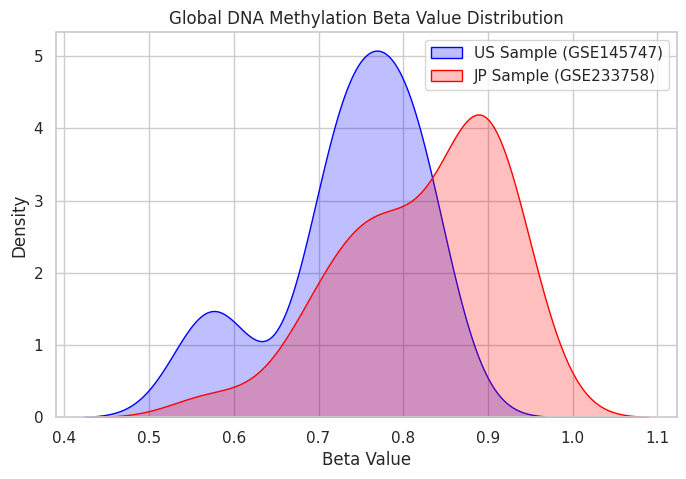

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Beta 值分佈
plt.figure(figsize=(8, 5))
sns.kdeplot(X_us_r.iloc[:, 0], label="US Sample (GSE145747)", fill=True, color='blue')
sns.kdeplot(X_jp_r.iloc[:, 0], label="JP Sample (GSE233758)", fill=True, color='red')

plt.title("Global DNA Methylation Beta Value Distribution")
plt.xlabel("Beta Value")
plt.ylabel("Density")
plt.legend()
plt.show()

## 找兩國 DMP 並進行ElasticNet


In [ ]:
from scipy._lib.array_api_compat import common

df_dmp_us = pd.read_csv(PATH + 'usa_DMP_result_TC.csv', index_col=0)
df_dmp_jp = pd.read_csv(PATH + 'jp_DMP_result_TC.csv', index_col=0)
df_deltabeta_us = pd.read_csv(PATH + 'usa_delta_beta_mean_values.csv', index_col=0)
df_deltabeta_jp = pd.read_csv(PATH + 'jp_delta_beta_mean_values.csv', index_col=0)

# 確保一致性
df_dmp_us.index = df_dmp_us.index.str.lower()
df_dmp_jp.index = df_dmp_jp.index.str.lower()
df_deltabeta_us.index = df_deltabeta_us.index.str.lower()
df_deltabeta_jp.index = df_deltabeta_jp.index.str.lower()

us_combined = df_dmp_us.join(df_deltabeta_us)
jp_combined = df_dmp_jp.join(df_deltabeta_jp)

us_pre_cpgs = us_combined[(us_combined['N_to_C.adj.P.Val'] < 0.01) & (us_combined['Delta_Beta_Mean'].abs() > 0.05)].index.intersection(X_us_r.columns)
jp_pre_cpgs = jp_combined[(jp_combined['N_to_C.adj.P.Val'] < 0.01) & (jp_combined['Delta_Beta_Mean'].abs() > 0.05)].index.intersection(X_jp_r.columns)

common_cpgs = us_pre_cpgs.intersection(jp_pre_cpgs)

print(f"美國 DMP 顯著 CpG 數量: {len(us_pre_cpgs)}")
print(f"日本 DMP 顯著 CpG 數量: {len(jp_pre_cpgs)}")
print(f"兩國都有的 CpG 數量: {len(common_cpgs)}")

美國 DMP 顯著 CpG 數量: 87451
日本 DMP 顯著 CpG 數量: 608
兩國都有的 CpG 數量: 204


In [ ]:
# from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV

# 萃取函數
def get_ElasticNet_features(X_df, y, feature_list, label):
    print(f"\n--- 正在對 {label} 進行 ElasticNet 特徵提取 ---")

    # 提取篩選後的特徵矩陣
    X_subset = X_df[feature_list].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_subset)

    # Elastic Net：結合了 LASSO(L1) 和 Ridge(L2) 兩種懲罰機制。特性是：會保留高度相關特徵的整個群體
    # 使用 l1_ratio=[0.1, 0.5, 0.9] 自動尋找最佳 LASSO 與 Ridge 特性比例
    ElasticNet_model = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], cv=5, random_state=42, max_iter=5000, n_jobs=-1)
    # lasso_model = LassoCV(cv=5, random_state=42, max_iter=5000, n_jobs=-1)
    ElasticNet_model.fit(X_scaled, y)

    selected_idx = np.where(ElasticNet_model.coef_ != 0)[0]
    final_cpgs = [feature_list[i] for i in selected_idx]

    print(f"  > 預篩選特徵數: {len(feature_list)}")
    print(f"  > ElasticNet 最終精煉出 {len(final_cpgs)} 個核心 CpG")

    return final_cpgs

# 兩國的 ElasticNet 特徵
us_ElasticNet_cpgs = get_ElasticNet_features(X_us_r, y_us, common_cpgs, "美國 (US)")
jp_ElasticNet_cpgs = get_ElasticNet_features(X_jp_r, y_jp, common_cpgs, "日本 (JP)")


--- 正在對 美國 (US) 進行 ElasticNet 特徵提取 ---
  > 預篩選特徵數: 204
  > ElasticNet 最終精煉出 44 個核心 CpG

--- 正在對 日本 (JP) 進行 ElasticNet 特徵提取 ---
  > 預篩選特徵數: 204
  > ElasticNet 最終精煉出 36 個核心 CpG


In [ ]:
# 原本 list，轉換為 DataFrame 再儲存
pd.DataFrame(us_ElasticNet_cpgs, columns=['CpG']).to_csv('/content/drive/MyDrive/Kidney_Methylation/us_lasso_cpgs_result.csv', index=False, encoding='utf-8-sig')
pd.DataFrame(jp_ElasticNet_cpgs, columns=['CpG']).to_csv('/content/drive/MyDrive/Kidney_Methylation/jp_lasso_cpgs_result.csv', index=False, encoding='utf-8-sig')
# 這樣就不用每次花40分鐘跑LASSO了:)

## 提取進行ElasticNet後，兩國各自的特徵基因

In [ ]:
# 從探針中萃取出所有不重複且非 NaN 的「基因清單」
def get_clean_genes(df, cpg_list):
    genes = df.loc[cpg_list, 'N_to_C.gene'].dropna().astype(str)
    # 處理 'GeneA;GeneB' 的情況，只取第一個
    clean_genes = [g.split(';')[0].strip() for g in genes if g.strip() != 'nan']
    return list(set(clean_genes))

us_ElasticNet_genes_df = pd.read_csv('/content/drive/MyDrive/Kidney_Methylation/us_lasso_cpgs_result.csv')
jp_ElasticNet_genes_df = pd.read_csv('/content/drive/MyDrive/Kidney_Methylation/jp_lasso_cpgs_result.csv')

us_ElasticNet_cpgs = us_ElasticNet_genes_df['CpG'].tolist()
jp_ElasticNet_cpgs = jp_ElasticNet_genes_df['CpG'].tolist()

us_ElasticNet_genes = get_clean_genes(df_dmp_us, us_ElasticNet_cpgs)
jp_ElasticNet_genes = get_clean_genes(df_dmp_jp, jp_ElasticNet_cpgs)

common_genes = set(us_ElasticNet_genes).intersection(set(jp_ElasticNet_genes))


print(f"\n萃取出的 美國 LASSO 基因數量: {len(us_ElasticNet_genes)}")
print(f"萃取出的 日本 LASSO 基因數量: {len(jp_ElasticNet_genes)}")
print(f"兩國都有的基因數量: {len(common_genes)}")
print(f"兩國都有的基因: {common_genes}")


萃取出的 美國 LASSO 基因數量: 33
萃取出的 日本 LASSO 基因數量: 27
兩國都有的基因數量: 10
兩國都有的基因: {'ANKRD11', 'CUX1', 'ODZ3', 'SNX29', 'NGEF', 'SLC25A18', 'NAV2', 'C9orf69', 'PRKAG2', 'ITGB5'}



### 5.1 Enrichr 功能富集分析 (GSEApy)
1. **US-Specific**: 美國顯著基因。
2. **JP-Specific**: 日本顯著基因。


In [ ]:
!pip install gseapy


【執行 ElasticNet 基因特徵的通路關聯探索】

--- 正在執行: US ElasticNet-Selected Genes (探索性閾值 p-value < 0.05) ---
P-value < 0.05 的通路數量: 137


,Gene_set,Term,Overlap,P-value
0,GO_Biological_Process_2026,Regulation of ATP Metabolic Process (GO:1903578),2/16,0.000312
1,GO_Biological_Process_2026,Potassium Ion Import Across Plasma Membrane (G...,2/46,0.002611
2,GO_Biological_Process_2026,Regulation of Microtubule Polymerization (GO:0...,2/51,0.003200
3,GO_Biological_Process_2026,Skeletal System Morphogenesis (GO:0048705),2/51,0.003200
4,GO_Biological_Process_2026,Positive Regulation of Protein Localization to...,1/5,0.008224
5,GO_Biological_Process_2026,Positive Regulation of Sphingolipid Biosynthet...,1/5,0.008224
6,GO_Biological_Process_2026,Positive Regulation of Ceramide Biosynthetic P...,1/5,0.008224
7,GO_Biological_Process_2026,Regulation of Platelet-Derived Growth Factor R...,1/5,0.008224
8,GO_Biological_Process_2026,Regulation of Chromosome Separation (GO:1905818),1/5,0.008224
9,GO_Biological_Process_2026,Negative Regulation of Organic Acid Transport ...,1/5,0.008224


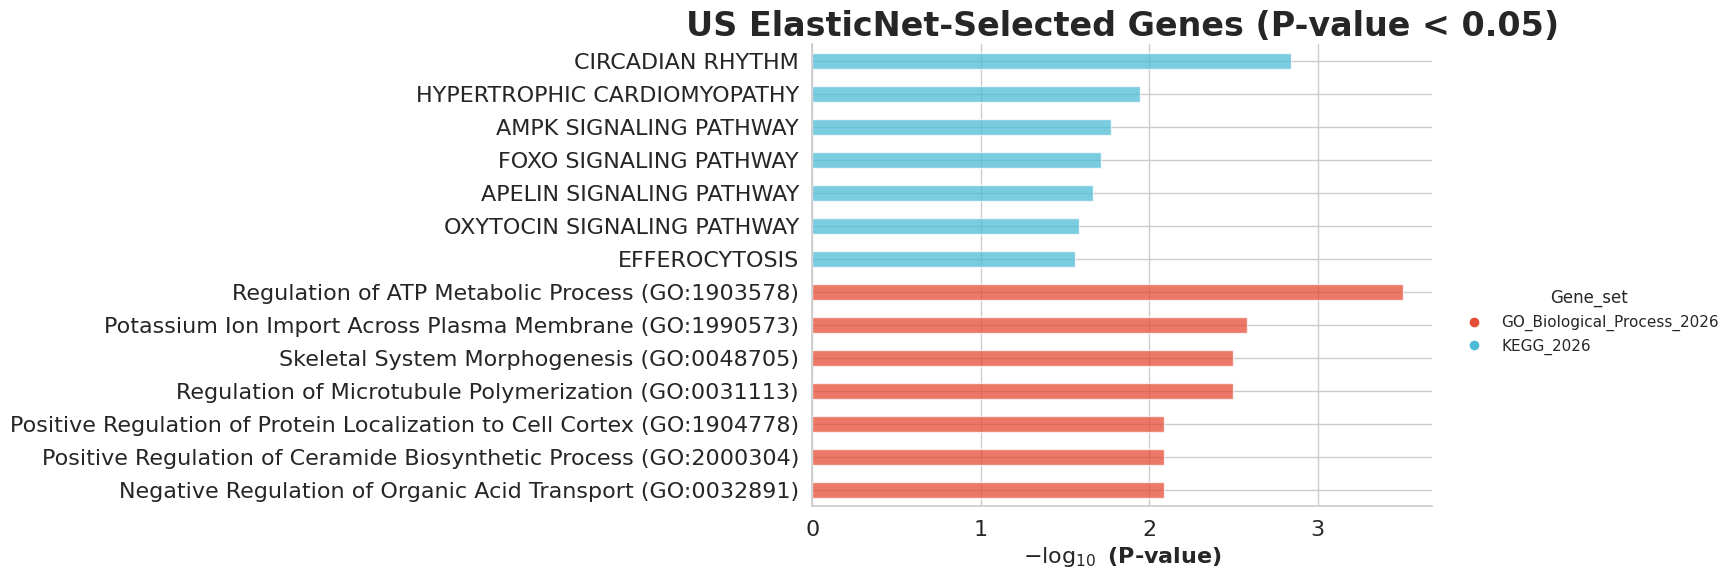


--- 正在執行: JP ElasticNet-Selected Genes (探索性閾值 p-value < 0.05) ---
P-value < 0.05 的通路數量: 94


,Gene_set,Term,Overlap,P-value
0,GO_Biological_Process_2026,Peptidyl-lysine Dimethylation (GO:0018027),1/5,0.006732
1,GO_Biological_Process_2026,Isocitrate Metabolic Process (GO:0006102),1/5,0.006732
2,GO_Biological_Process_2026,Positive Regulation of Protein Deubiquitinatio...,1/6,0.008074
3,GO_Biological_Process_2026,Positive Regulation of Cell-Cell Adhesion Medi...,1/7,0.009413
4,GO_Biological_Process_2026,Negative Regulation of Dendritic Spine Develop...,1/7,0.009413
5,GO_Biological_Process_2026,Cell-matrix Adhesion (GO:0007160),2/116,0.010649
6,GO_Biological_Process_2026,Regulation of Protein Deubiquitination (GO:009...,1/8,0.010751
7,GO_Biological_Process_2026,Positive Regulation of Myotube Differentiation...,1/8,0.010751
8,GO_Biological_Process_2026,Malate-aspartate Shuttle (GO:0043490),1/9,0.012087
9,GO_Biological_Process_2026,Alpha-linolenic Acid Metabolic Process (GO:003...,1/10,0.013421


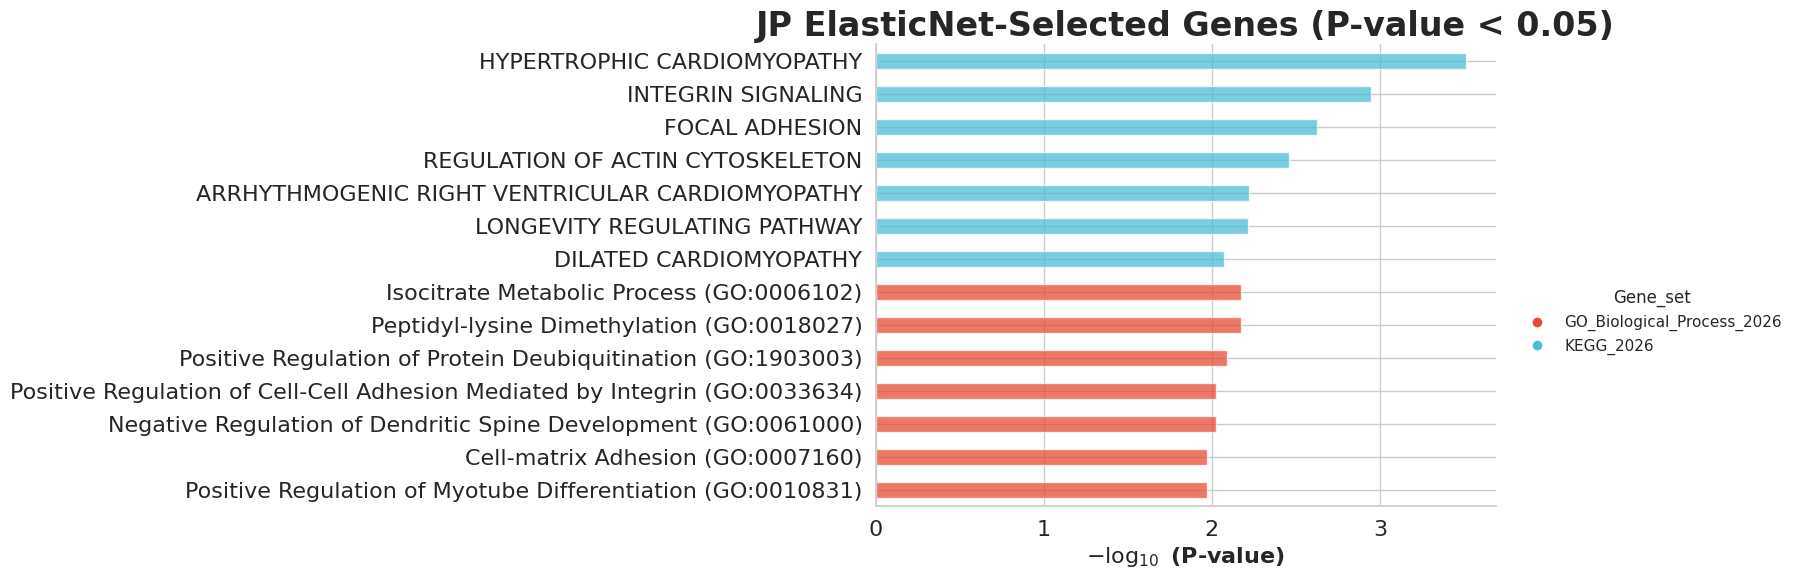

In [ ]:
import gseapy as gp
import matplotlib.pyplot as plt
from gseapy import barplot

# 因為富集分析結果跑出來的 pathway 的過少，所以使用 p-value
def run_enrichr_custom(gene_list, title, cutoff):
    print(f"\n--- 正在執行: {title} (探索性閾值 p-value < {cutoff}) ---")
    if not gene_list or len(gene_list) < 3:
        print("基因清單過少，跳過分析。")
        return None

    # 執行 Enrichr 查詢
    enr = gp.enrichr(gene_list=gene_list,
                     gene_sets=['GO_Biological_Process_2026', 'KEGG_2026'],
                     organism='human',
                     outdir=None)

    if enr.results.empty:
        print("無富集結果。")
        return enr

    sig_results = enr.results[enr.results['P-value'] < cutoff]
    print(f"P-value < {cutoff} 的通路數量: {len(sig_results)}")

    if sig_results.empty:
        print(f"uhh... 沒有 P-value < {cutoff} 的通路。")
    else:
        display(sig_results[['Gene_set', 'Term', 'Overlap', 'P-value']].head(15))

        # 繪圖
        try:
            ax = barplot(enr.results,
                         column="P-value",
                         group='Gene_set',
                         size=10,
                         top_term=7,
                         cutoff=cutoff,
                         figsize=(8, 6),
                         title=f"{title} (P-value < {cutoff})",
                         color=['#E64B35', '#4DBBD5'])
            plt.show()
        except Exception as e:
            print(f"繪圖失敗: {e}")

    return sig_results

# 執行分析
print("\n" + "="*50)
print("【執行 ElasticNet 基因特徵的通路關聯探索】")
print("="*50)
enr_us_ElasticNet = run_enrichr_custom(us_ElasticNet_genes, "US ElasticNet-Selected Genes", cutoff=0.05)
enr_jp_ElasticNet = run_enrichr_custom(jp_ElasticNet_genes, "JP ElasticNet-Selected Genes", cutoff=0.05)

In [ ]:
df_us = enr_us_ElasticNet
df_jp = enr_jp_ElasticNet

set_us = set(df_us['Term'])
set_jp = set(df_jp['Term'])

common_pathways = set_us.intersection(set_jp)
print(f"兩國共有的通路數量: {len(common_pathways)}")
display(common_pathways)

df_common_us = df_us[df_us['Term'].isin(common_pathways)].set_index('Term')
df_common_jp = df_jp[df_jp['Term'].isin(common_pathways)].set_index('Term')

df_intersection = df_common_us.join(df_common_jp, lsuffix='_US', rsuffix='_JP')
display(df_intersection.head())

兩國共有的通路數量: 37


{'ATP Biosynthetic Process (GO:0006754)',
 'Acidic Amino Acid Transport (GO:0015800)',
 'Aspartate Transmembrane Transport (GO:0015810)',
 'C4-dicarboxylate Transport (GO:0015740)',
 'CIRCADIAN RHYTHM',
 'Cell-matrix Adhesion (GO:0007160)',
 'Contractile Actin Filament Bundle Assembly (GO:0030038)',
 'Energy Reserve Metabolic Process (GO:0006112)',
 'Epithelial Cell-Cell Adhesion (GO:0090136)',
 'Glucan Metabolic Process (GO:0044042)',
 'Glycogen Metabolic Process (GO:0005977)',
 'HYPERTROPHIC CARDIOMYOPATHY',
 'L-glutamate Import (GO:0051938)',
 'L-glutamate Transmembrane Transport (GO:0015813)',
 'Malate-aspartate Shuttle (GO:0043490)',
 'NAD+ Metabolic Process (GO:0019674)',
 'Negative Regulation of Dendritic Spine Development (GO:0061000)',
 'OXYTOCIN SIGNALING PATHWAY',
 'Odontogenesis of Dentin-Containing Tooth (GO:0042475)',
 'Positive Regulation of Cell Morphogenesis (GO:0010770)',
 'Positive Regulation of Dendrite Morphogenesis (GO:0050775)',
 'Positive Regulation of Gluconeog

,Gene_set_US,Overlap_US,P-value_US,Adjusted P-value_US,Old P-value_US,Old Adjusted P-value_US,Odds Ratio_US,Combined Score_US,Genes_US,Gene_set_JP,Overlap_JP,P-value_JP,Adjusted P-value_JP,Old P-value_JP,Old Adjusted P-value_JP,Odds Ratio_JP,Combined Score_JP,Genes_JP
Term,,,,,,,,,,,,,,,,,,
Regulation of ATP Metabolic Process (GO:1903578),GO_Biological_Process_2026,2/16,0.000312,0.111163,0,0,91.949309,742.186161,SPHK2;PRKAG2,GO_Biological_Process_2026,1/16,0.021390,0.10949,0,0,51.174359,196.755709,PRKAG2
Negative Regulation of Dendritic Spine Development (GO:0061000),GO_Biological_Process_2026,1/7,0.011495,0.122625,0,0,103.963542,464.288587,NGEF,GO_Biological_Process_2026,1/7,0.009413,0.10949,0,0,127.993590,597.173389,NGEF
Malate-aspartate Shuttle (GO:0043490),GO_Biological_Process_2026,1/9,0.014755,0.122625,0,0,77.964844,328.712393,SLC25A18,GO_Biological_Process_2026,1/9,0.012087,0.10949,0,0,95.985577,423.837198,SLC25A18
Cell-matrix Adhesion (GO:0007160),GO_Biological_Process_2026,2/116,0.015661,0.122625,0,0,11.235427,46.700785,ITGB5;MSLN,GO_Biological_Process_2026,2/116,0.010649,0.10949,0,0,13.936140,63.302287,ITGB5;ACTN1
Positive Regulation of Cell Morphogenesis (GO:0010770),GO_Biological_Process_2026,1/11,0.018005,0.122625,0,0,62.365625,250.528195,CUX1,GO_Biological_Process_2026,1/11,0.014754,0.10949,0,0,76.780769,323.727778,CUX1


## 找出在美、日兩邊都命中的 Overlapping Genes，取CpG

In [ ]:
# index不再用'Term'
df_common_us = df_us[df_us['Term'].isin(common_pathways)]
df_common_jp = df_jp[df_jp['Term'].isin(common_pathways)]

us_genes_str = df_common_us['Genes'].str.replace(';', ',').str.cat(sep=',')
jp_genes_str = df_common_jp['Genes'].str.replace(';', ',').str.cat(sep=',')

# 轉為 Set 並清除可能的空白
us_genes = {g.strip() for g in us_genes_str.split(',')}
jp_genes = {g.strip() for g in jp_genes_str.split(',')}
us_genes.discard('')
jp_genes.discard('')

# display(us_genes)
# display(jp_genes)

core_genes = us_genes.intersection(jp_genes)

print(f"US 命中了 {len(us_genes)} 個基因")      # 美國病患的資料中，ElasticNet 模型所挑選出來的基因
print(f"JP 命中了 {len(jp_genes)} 個基因")      # 日本病患的資料中，ElasticNet 模型所挑選出來的基因
print(f"跨國核心基因都有 {len(core_genes)} 個：\n", core_genes)

US 命中了 10 個基因
JP 命中了 8 個基因
跨國核心基因都有 6 個：
 {'ANKRD11', 'CUX1', 'NGEF', 'SLC25A18', 'PRKAG2', 'ITGB5'}


In [ ]:
def find_core_cpgs(df, core_genes_set):
    def is_core(gene_str):
        if pd.isna(gene_str): return False
        genes = [g.strip() for g in str(gene_str).split(';')]
        return any(g in core_genes_set for g in genes)
    mask = df['N_to_C.gene'].apply(is_core)
    return df[mask].index.tolist()

us_core_cpgs = find_core_cpgs(df_dmp_us, core_genes)
jp_core_cpgs = find_core_cpgs(df_dmp_jp, core_genes)

# 找出基因對應的 CpG 交集
intersection_genes_to_cpgs = list(set(us_core_cpgs).intersection(set(jp_core_cpgs)))

us_delta_core = us_combined.loc[intersection_genes_to_cpgs, 'Delta_Beta_Mean']
jp_delta_core = jp_combined.loc[intersection_genes_to_cpgs, 'Delta_Beta_Mean']
same_direction_mask = (np.sign(us_delta_core) == np.sign(jp_delta_core))

true_common_cpgs = set(same_direction_mask[same_direction_mask].index)
flipped_cpgs = set(same_direction_mask[~same_direction_mask].index)

print(f"美國核心基因相關 CpG: {len(us_core_cpgs)}")
print(f"日本核心基因相關 CpG: {len(jp_core_cpgs)}")
print(f"兩國交集 CpG 總數: {len(intersection_genes_to_cpgs)}")
print(f"其中同向 (true_common): {len(true_common_cpgs)}")
print(f"其中反向 (flipped): {len(flipped_cpgs)}")

美國核心基因相關 CpG: 246
日本核心基因相關 CpG: 44
兩國交集 CpG 總數: 31
其中同向 (true_common): 29
其中反向 (flipped): 2


原始提取特徵數: 29
【實驗 A】US 訓練 -> JP 測試 
 訓練集數: 31 
| RF AUC: 0.9271 | LR AUC: 0.9625
【實驗 B】JP 訓練 -> US 測試 
 訓練集數: 24 
| RF AUC: 0.9931 | LR AUC: 0.9861


/tmp/ipykernel_3095/3220376334.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_us.values, y=importances_us.index, ax=axes[1, 0], palette="viridis")
/tmp/ipykernel_3095/3220376334.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_jp.values, y=importances_jp.index, ax=axes[1, 1], palette="magma")


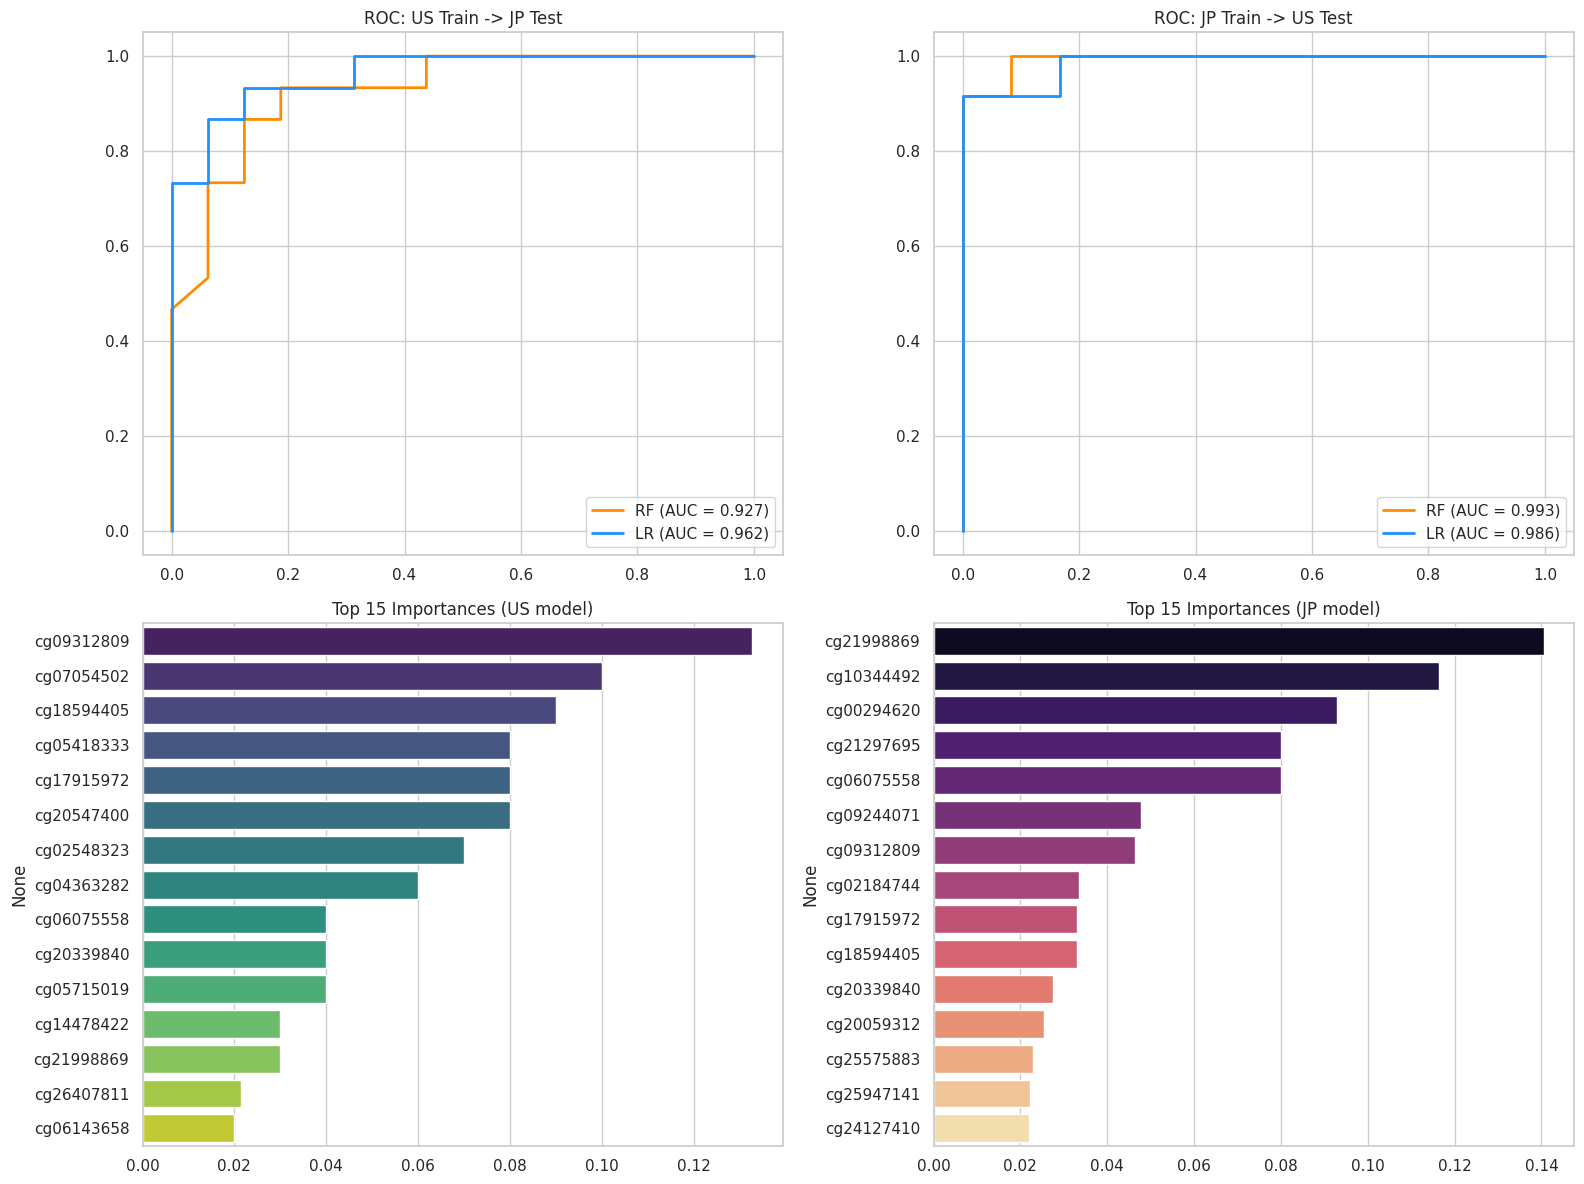

【29 個跨國核心 CpG 甲基化方向檢查】


,US_DeltaBeta,JP_DeltaBeta,Gene,Direction_Flipped?
cg25575883,0.143182,0.221333,SLC25A18,False
cg02307880,0.188698,0.201298,CUX1,False
cg17915972,-0.164191,-0.100265,NGEF,False
cg09300089,0.097674,0.175558,ANKRD11,False
cg10344492,0.095490,0.274897,NGEF,False
cg18594405,0.226293,0.183969,CUX1,False
cg07054502,0.164032,0.147369,ANKRD11,False
cg21297695,-0.081695,-0.154060,PRKAG2,False
cg00294620,0.129324,0.210343,PRKAG2,False
cg02548323,0.409347,0.232627,CUX1,False


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

final_cpg_features = list(true_common_cpgs)

print(f"原始提取特徵數: {len(final_cpg_features)}")

X_us_ml = X_us_r[final_cpg_features]
X_jp_ml = X_jp_r[final_cpg_features]

X_us_normal = X_us_ml[y_us == 0]
X_jp_normal = X_jp_ml[y_jp == 0]

scaler_us = StandardScaler()
scaler_jp = StandardScaler()

# 只用 Normal 樣本來學習 (fit) 基準線與尺度
scaler_us.fit(X_us_normal)
scaler_jp.fit(X_jp_normal)

# 將學習到的健康基準線，transform 到該國的所有樣本上
X_us_scaled = pd.DataFrame(scaler_us.transform(X_us_ml), columns=final_cpg_features)
X_jp_scaled = pd.DataFrame(scaler_jp.transform(X_jp_ml), columns=final_cpg_features)

# 初始化
rf_us = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
lr_us = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
rf_jp = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
lr_jp = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')


# --- US 訓練 -> JP 測試 ---
rf_us.fit(X_us_scaled, y_us)
lr_us.fit(X_us_scaled, y_us)
rf_jp_preds = rf_us.predict_proba(X_jp_scaled)[:, 1]
lr_jp_preds = lr_us.predict_proba(X_jp_scaled)[:, 1]
auc_rf_us_to_jp = roc_auc_score(y_jp, rf_jp_preds)
auc_lr_us_to_jp = roc_auc_score(y_jp, lr_jp_preds)

# --- JP 訓練 -> US 測試 ---
rf_jp.fit(X_jp_scaled, y_jp)
lr_jp.fit(X_jp_scaled, y_jp)
rf_us_preds = rf_jp.predict_proba(X_us_scaled)[:, 1]
lr_us_preds = lr_jp.predict_proba(X_us_scaled)[:, 1]
auc_rf_jp_to_us = roc_auc_score(y_us, rf_us_preds)
auc_lr_jp_to_us = roc_auc_score(y_us, lr_us_preds)

print(f"【實驗 A】US 訓練 -> JP 測試 \n 訓練集數: {len(X_jp_ml)} \n| RF AUC: {auc_rf_us_to_jp:.4f} | LR AUC: {auc_lr_us_to_jp:.4f}")
print(f"【實驗 B】JP 訓練 -> US 測試 \n 訓練集數: {len(X_us_ml)} \n| RF AUC: {auc_rf_jp_to_us:.4f} | LR AUC: {auc_lr_jp_to_us:.4f}")


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")

# ROC 曲線
fpr_rf_1, tpr_rf_1, _ = roc_curve(y_jp, rf_jp_preds)
fpr_lr_1, tpr_lr_1, _ = roc_curve(y_jp, lr_jp_preds)
axes[0, 0].plot(fpr_rf_1, tpr_rf_1, label=f'RF (AUC = {auc_rf_us_to_jp:.3f})', color='darkorange', lw=2)
axes[0, 0].plot(fpr_lr_1, tpr_lr_1, label=f'LR (AUC = {auc_lr_us_to_jp:.3f})', color='dodgerblue', lw=2)
axes[0, 0].set_title("ROC: US Train -> JP Test")
axes[0, 0].legend()

fpr_rf_2, tpr_rf_2, _ = roc_curve(y_us, rf_us_preds)
fpr_lr_2, tpr_lr_2, _ = roc_curve(y_us, lr_us_preds)
axes[0, 1].plot(fpr_rf_2, tpr_rf_2, label=f'RF (AUC = {auc_rf_jp_to_us:.3f})', color='darkorange', lw=2)
axes[0, 1].plot(fpr_lr_2, tpr_lr_2, label=f'LR (AUC = {auc_lr_jp_to_us:.3f})', color='dodgerblue', lw=2)
axes[0, 1].set_title("ROC: JP Train -> US Test")
axes[0, 1].legend()

# 特徵重要性
importances_us = pd.Series(rf_us.feature_importances_, index=final_cpg_features).sort_values(ascending=False).head(15)
sns.barplot(x=importances_us.values, y=importances_us.index, ax=axes[1, 0], palette="viridis")
axes[1, 0].set_title("Top 15 Importances (US model)")

importances_jp = pd.Series(rf_jp.feature_importances_, index=final_cpg_features).sort_values(ascending=False).head(15)
sns.barplot(x=importances_jp.values, y=importances_jp.index, ax=axes[1, 1], palette="magma")
axes[1, 1].set_title("Top 15 Importances (JP model)")

plt.tight_layout()
plt.show()

# final_cpg_features 是你找到的那 13 個交集 CpG 的 list
# 抓出這 29 個 CpG 在兩國的 Delta Beta
check_direction_df = pd.DataFrame({
    'US_DeltaBeta': df_dmp_us.loc[final_cpg_features, 'N_to_C.deltaBeta'],
    'JP_DeltaBeta': df_dmp_jp.loc[final_cpg_features, 'N_to_C.deltaBeta'],
    'Gene': df_dmp_us.loc[final_cpg_features, 'N_to_C.gene']
})

# 判斷方向是否相反
check_direction_df['Direction_Flipped?'] = np.sign(check_direction_df['US_DeltaBeta']) != np.sign(check_direction_df['JP_DeltaBeta'])

print(f"【{len(check_direction_df)} 個跨國核心 CpG 甲基化方向檢查】")
display(check_direction_df)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def calculate_metrics(y_true, y_pred_prob, threshold=0.5):
    y_pred = (y_pred_prob >= threshold).astype(int)
    return {
        'ACC': accuracy_score(y_true, y_pred),
        'Pre': precision_score(y_true, y_pred),
        'Sen': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred)
    }

# US -> JP
m_rf_us_jp = calculate_metrics(y_jp, rf_jp_preds)
m_lr_us_jp = calculate_metrics(y_jp, lr_jp_preds)

# JP -> US
m_rf_jp_us = calculate_metrics(y_us, rf_us_preds)
m_lr_jp_us = calculate_metrics(y_us, lr_us_preds)

metrics_df = pd.DataFrame({
    'Scenario': ['US->JP (RF)', 'US->JP (LR)', 'JP->US (RF)', 'JP->US (LR)'],
    'AUC': [auc_rf_us_to_jp, auc_lr_us_to_jp, auc_rf_jp_to_us, auc_lr_jp_to_us],
    'Accuracy': [m_rf_us_jp['ACC'], m_lr_us_jp['ACC'], m_rf_jp_us['ACC'], m_lr_jp_us['ACC']],
    'Precision': [m_rf_us_jp['Pre'], m_lr_us_jp['Pre'], m_rf_jp_us['Pre'], m_lr_jp_us['Pre']],
    'Sensitivity': [m_rf_us_jp['Sen'], m_lr_us_jp['Sen'], m_rf_jp_us['Sen'], m_lr_jp_us['Sen']],
    'F1-score': [m_rf_us_jp['F1'], m_lr_us_jp['F1'], m_rf_jp_us['F1'], m_lr_jp_us['F1']]
})

print("【Cross-Cohort Validation Metrics Summary】")
display(metrics_df)

【Cross-Cohort Validation Metrics Summary】


,Scenario,AUC,Accuracy,Precision,Sensitivity,F1-score
0,US->JP (RF),0.927083,0.838710,0.916667,0.733333,0.814815
1,US->JP (LR),0.962500,0.806452,1.000000,0.600000,0.750000
2,JP->US (RF),0.993056,0.916667,0.916667,0.916667,0.916667
3,JP->US (LR),0.986111,0.875000,1.000000,0.750000,0.857143


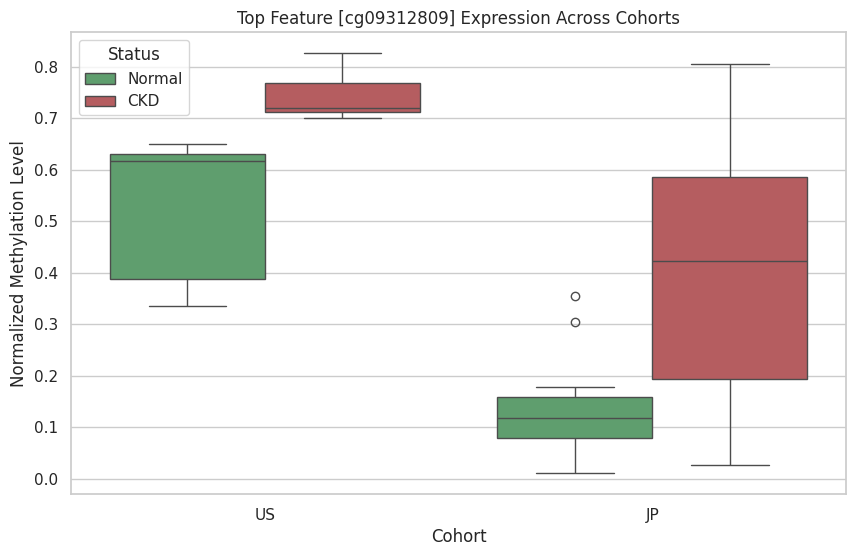

In [ ]:
# 1. 找出 US 模型中最重要的特徵
top_feature_name = importances_us.index[0]

# 2. 準備畫圖用的 DataFrame
# 將 US 和 JP 的該特徵數據合併，並標註 Cohort 和 Status
df_us_plot = pd.DataFrame({
    'Methylation_Level': X_us_ml[top_feature_name], # 已經做過 rank norm 的數值
    'Status': y_us,
    'Cohort': 'US'
})

df_jp_plot = pd.DataFrame({
    'Methylation_Level': X_jp_ml[top_feature_name],
    'Status': y_jp,
    'Cohort': 'JP'
})

# 合併兩國資料
df_combined = pd.concat([df_us_plot, df_jp_plot])
df_combined['Status'] = df_combined['Status'].replace({0: 'Normal', 1: 'CKD'})

# 3. 繪製跨 Cohort 的特徵箱型圖
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cohort', y='Methylation_Level', hue='Status', data=df_combined,
            palette={'Normal': '#55a868', 'CKD': '#c44e52'})

plt.title(f'Top Feature [{top_feature_name}] Expression Across Cohorts')
plt.xlabel('Cohort')
plt.ylabel('Normalized Methylation Level')
plt.legend(title='Status')
plt.show()

⏳ 正在執行 100 次重複抽樣驗證 (US 80% -> JP All)...


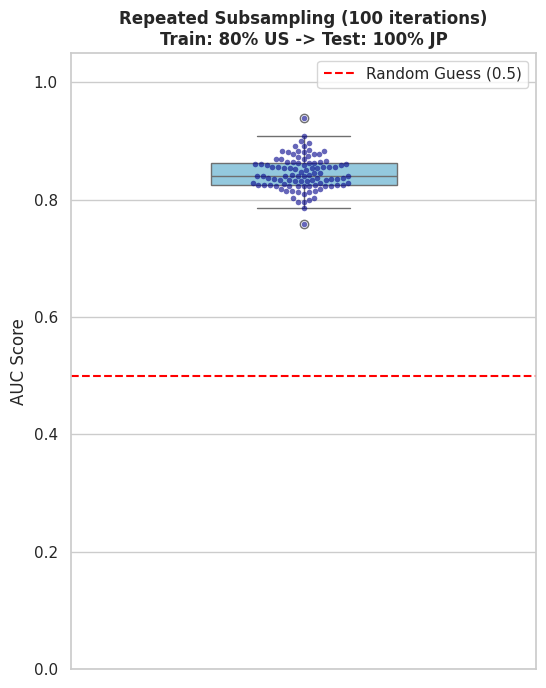

✅ 完成！
📊 100 次平均 AUC: 0.8450
📈 95% 信賴區間 (CI): [0.7958, 0.8980]


In [ ]:
from sklearn.model_selection import train_test_split

# 重複次數
n_iterations = 100
auc_scores = []

print("⏳ 正在執行 100 次重複抽樣驗證 (US 80% -> JP All)...")

for i in range(n_iterations):
    # 隨機抽取 80% 的 US 資料作為訓練集 (stratify 確保 Normal/CKD 比例一致)
    X_us_train, _, y_us_train, _ = train_test_split(
        X_us_ml, y_us, test_size=0.2, stratify=y_us, random_state=i
    )

    # 獨立標準化 (每次只用抽出來的 80% 來計算 mean/std，避免洩漏)
    scaler_us = StandardScaler()
    X_us_train_scaled = pd.DataFrame(scaler_us.fit_transform(X_us_train), columns=final_cpg_features)

    scaler_jp = StandardScaler()
    X_jp_scaled = pd.DataFrame(scaler_jp.fit_transform(X_jp_ml), columns=final_cpg_features)

    # 訓練 Random Forest
    rf = RandomForestClassifier(random_state=i, n_jobs=-1)
    rf.fit(X_us_train, y_us_train)

    # 預測日本全部樣本並記錄 AUC
    preds = rf.predict_proba(X_jp_ml)[:, 1]
    auc = roc_auc_score(y_jp, preds)
    auc_scores.append(auc)

# 計算統計數據
mean_auc = np.mean(auc_scores)
ci_lower = np.percentile(auc_scores, 2.5)
ci_upper = np.percentile(auc_scores, 97.5)

# --- 繪製 Boxplot ---
plt.figure(figsize=(6, 8))
sns.boxplot(y=auc_scores, color="skyblue", width=0.4)
sns.swarmplot(y=auc_scores, color="darkblue", size=4, alpha=0.6) # 加上散佈點看分佈
plt.title("Repeated Subsampling (100 iterations)\nTrain: 80% US -> Test: 100% JP", fontweight='bold')
plt.ylabel("AUC Score", fontsize=12)
plt.ylim(0, 1.05)
plt.axhline(0.5, color='red', linestyle='--', label='Random Guess (0.5)')
plt.legend()
plt.show()

print(f"✅ 完成！")
print(f"📊 100 次平均 AUC: {mean_auc:.4f}")
print(f"📈 95% 信賴區間 (CI): [{ci_lower:.4f}, {ci_upper:.4f}]")

⏳ 正在再次執行 100 次重複抽樣驗證 (JP 80% -> US All)...


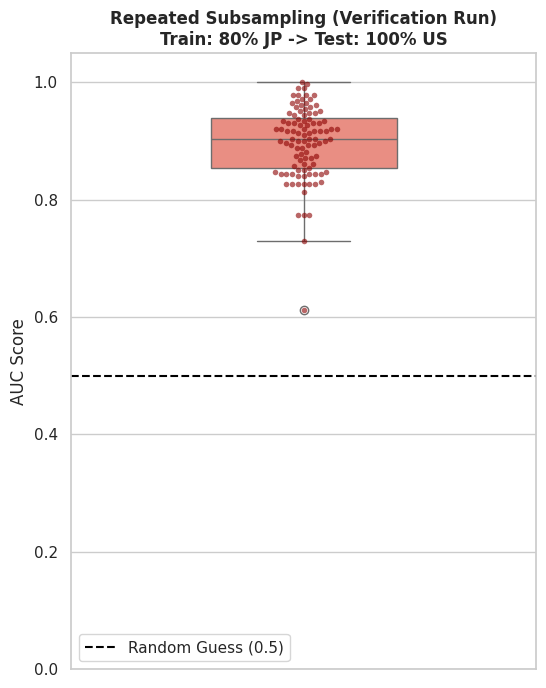

✅ 完成！
📊 再次執行平均 AUC: 0.8975
📈 95% 信賴區間 (CI): [0.7743, 0.9896]


In [ ]:
from sklearn.model_selection import train_test_split

# 重複次數
n_iterations = 100
auc_scores_repeat = []

print("⏳ 正在再次執行 100 次重複抽樣驗證 (JP 80% -> US All)...")

for i in range(n_iterations):
    # 隨機抽取 80% 的 JP 資料作為訓練集 (使用不同的隨機種子以確保多樣性)
    X_jp_train, _, y_jp_train, _ = train_test_split(
        X_jp_ml, y_jp, test_size=0.2, stratify=y_jp, random_state=i + 500
    )

    # 訓練 Random Forest (直接使用 ml 矩陣，略過 Scaling，因 RF 對 Scaling 不敏感)
    rf_repeat = RandomForestClassifier(random_state=i + 500, n_jobs=-1)
    rf_repeat.fit(X_jp_train, y_jp_train)

    # 預測美國全部樣本並記錄 AUC
    preds_repeat = rf_repeat.predict_proba(X_us_ml)[:, 1]
    auc_val = roc_auc_score(y_us, preds_repeat)
    auc_scores_repeat.append(auc_val)

# 計算統計數據
mean_auc_rep = np.mean(auc_scores_repeat)
ci_lower_rep = np.percentile(auc_scores_repeat, 2.5)
ci_upper_rep = np.percentile(auc_scores_repeat, 97.5)

# --- 繪製分佈圖 ---
plt.figure(figsize=(6, 8))
sns.boxplot(y=auc_scores_repeat, color="salmon", width=0.4)
sns.swarmplot(y=auc_scores_repeat, color="darkred", size=4, alpha=0.6)
plt.title("Repeated Subsampling (Verification Run)\nTrain: 80% JP -> Test: 100% US", fontweight='bold')
plt.ylabel("AUC Score", fontsize=12)
plt.ylim(0, 1.05)
plt.axhline(0.5, color='black', linestyle='--', label='Random Guess (0.5)')
plt.legend()
plt.show()

print(f"✅ 完成！")
print(f"📊 再次執行平均 AUC: {mean_auc_rep:.4f}")
print(f"📈 95% 信賴區間 (CI): [{ci_lower_rep:.4f}, {ci_upper_rep:.4f}]")

/tmp/ipykernel_3095/3225847810.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='True_Label', y='RF_Predicted_Prob', data=df,
/tmp/ipykernel_3095/3225847810.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='True_Label', y='LR_Predicted_Prob', data=df,


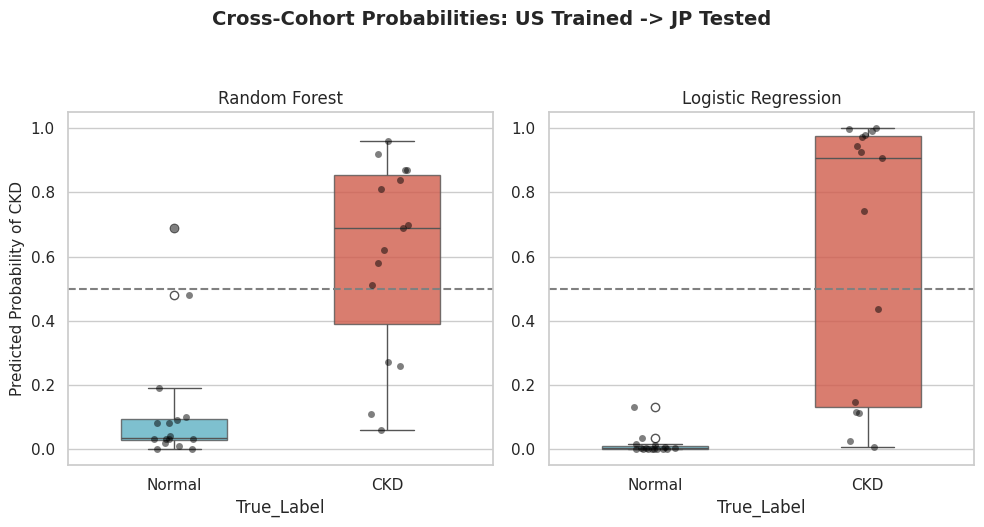

/tmp/ipykernel_3095/3225847810.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='True_Label', y='RF_Predicted_Prob', data=df,
/tmp/ipykernel_3095/3225847810.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='True_Label', y='LR_Predicted_Prob', data=df,


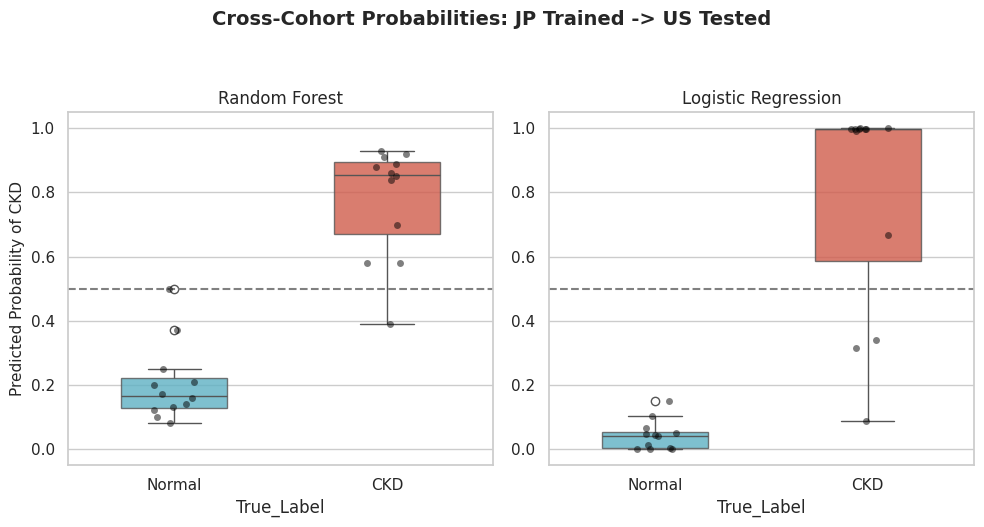

In [ ]:
# 建立 US 訓練 -> JP 測試 的預測機率 DataFrame
df_us_to_jp = pd.DataFrame({
    'True_Label': ['CKD' if y == 1 else 'Normal' for y in y_jp],
    'RF_Predicted_Prob': rf_jp_preds,
    'LR_Predicted_Prob': lr_jp_preds
})

# 建立 JP 訓練 -> US 測試 的預測機率 DataFrame
df_jp_to_us = pd.DataFrame({
    'True_Label': ['CKD' if y == 1 else 'Normal' for y in y_us],
    'RF_Predicted_Prob': rf_us_preds,
    'LR_Predicted_Prob': lr_us_preds
})

def plot_prob_boxplot(df, title):
    plt.figure(figsize=(10, 5))

    # --- Random Forest ---
    plt.subplot(1, 2, 1)
    # boxplot
    sns.boxplot(x='True_Label', y='RF_Predicted_Prob', data=df,
                palette={'Normal':'#4DBBD5', 'CKD':'#E64B35'}, width=0.5, boxprops=dict(alpha=0.8))
    # 疊加真實資料點 (Stripplot) 讓分佈更清楚
    sns.stripplot(x='True_Label', y='RF_Predicted_Prob', data=df,
                  color='black', alpha=0.5, jitter=True, size=5)

    # 畫出 0.5 的決策邊界 (大於 0.5 判定為患病)
    plt.axhline(0.5, color='gray', linestyle='--', linewidth=1.5)
    plt.title('Random Forest', fontsize=12)
    plt.ylabel('Predicted Probability of CKD', fontsize=11)
    plt.ylim(-0.05, 1.05)

    # --- Logistic Regression ---
    plt.subplot(1, 2, 2)
    sns.boxplot(x='True_Label', y='LR_Predicted_Prob', data=df,
                palette={'Normal':'#4DBBD5', 'CKD':'#E64B35'}, width=0.5, boxprops=dict(alpha=0.8))
    sns.stripplot(x='True_Label', y='LR_Predicted_Prob', data=df,
                  color='black', alpha=0.5, jitter=True, size=5)
    plt.axhline(0.5, color='gray', linestyle='--', linewidth=1.5)
    plt.title('Logistic Regression', fontsize=12)
    plt.ylabel('')
    plt.ylim(-0.05, 1.05)

    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# 繪圖
plot_prob_boxplot(df_us_to_jp, 'Cross-Cohort Probabilities: US Trained -> JP Tested')
plot_prob_boxplot(df_jp_to_us, 'Cross-Cohort Probabilities: JP Trained -> US Tested')

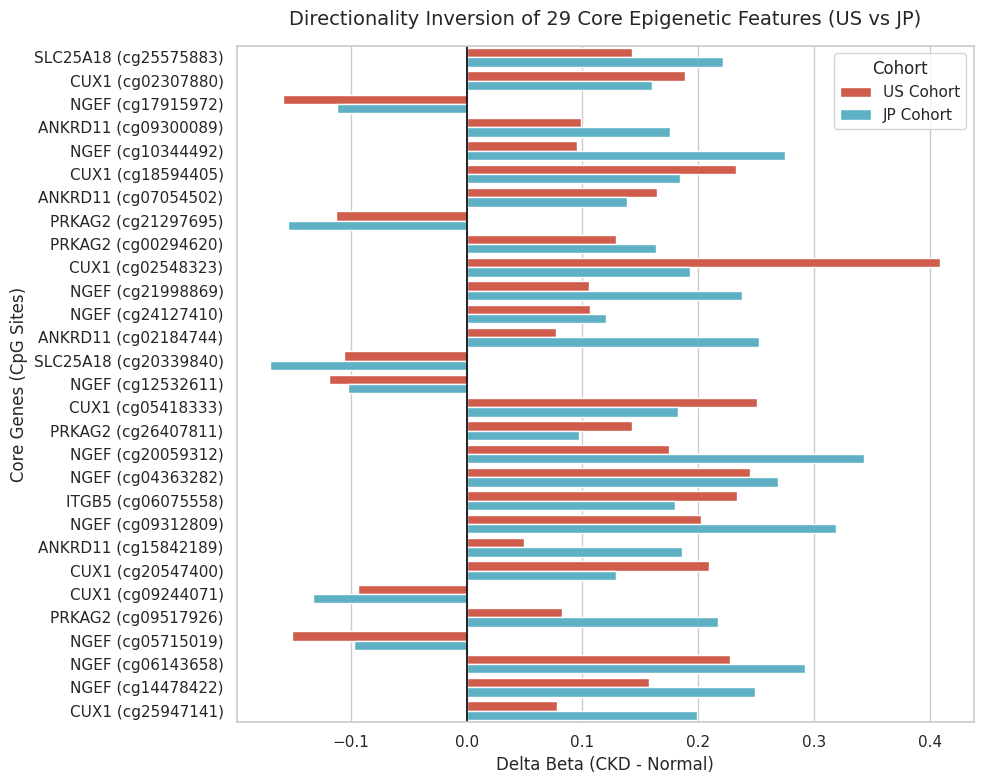

In [ ]:
df_plot = pd.DataFrame({
    'CpG': final_cpg_features,
    'US_DeltaBeta': us_combined.loc[final_cpg_features, 'Delta_Beta_Mean'].values,
    'JP_DeltaBeta': jp_combined.loc[final_cpg_features, 'Delta_Beta_Mean'].values,
    'Gene': us_combined.loc[final_cpg_features, 'N_to_C.gene'].values
})

# 只取第一個基因名稱
df_plot['Gene'] = df_plot['Gene'].astype(str).apply(lambda x: x.split(';')[0] if x != 'nan' else 'Intergenic')
df_plot['Label'] = df_plot['Gene'] + " (" + df_plot['CpG'] + ")"

# 將資料轉為長格式 (Long format) 方便 Seaborn 繪圖
df_melted = df_plot.melt(id_vars=['Label'], value_vars=['US_DeltaBeta', 'JP_DeltaBeta'],
                         var_name='Cohort', value_name='DeltaBeta')
df_melted['Cohort'] = df_melted['Cohort'].map({'US_DeltaBeta': 'US Cohort', 'JP_DeltaBeta': 'JP Cohort'})

# 繪製背離長條圖
plt.figure(figsize=(10, 8))
sns.barplot(data=df_melted, y='Label', x='DeltaBeta', hue='Cohort', palette={'US Cohort': '#E64B35', 'JP Cohort': '#4DBBD5'})

plt.axvline(0, color='black', linewidth=1.2)
plt.title('Directionality Inversion of 29 Core Epigenetic Features (US vs JP)', fontsize=14, pad=15)
plt.xlabel('Delta Beta (CKD - Normal)', fontsize=12)
plt.ylabel('Core Genes (CpG Sites)', fontsize=12)
plt.legend(title='Cohort')
plt.tight_layout()
plt.show()

# 6. 視覺化一致性 CpG 的甲基化分佈
我們使用熱圖 (Heatmap) 來觀察這 13 個 CpG 位點在兩國樣本中的表現。由於資料已經過 Rank Normalization，數值介於 0 到 1 之間。

In [ ]:
import urllib.parse
from IPython.display import HTML

# 1. 將你取出的基因轉換為 List (請確保 us_genes 和 jp_genes 是你前面跑出來的 set)
list_us_genes = list(us_genes)
list_jp_genes = list(jp_genes)
list_core_genes = list(core_genes)

# 2. 建立 DataFrame
df_genes_review = pd.DataFrame({
    'Gene_Symbol': list_core_genes
})

# 3. 定義轉成 GeneCards 連結的函數
def make_clickable(gene):
    return f'<a target="_blank" href="https://www.genecards.org/cgi-bin/carddisp.pl?gene={gene}"><b style="color:blue;">{gene}</b></a>'

# 4. 套用連結並顯示
df_genes_review['GeneCards_Literature_Link'] = df_genes_review['Gene_Symbol'].apply(make_clickable)

print("【第一板塊：核心基因文獻查詢表】(請點擊藍色基因名稱查詢其生物學功能)")
display(HTML(df_genes_review.to_html(escape=False, index=False)))



# 1. 將你取出的通路轉換為 List (確保 common_pathways 是你前面跑出來的 set)
list_pathways = list(common_pathways)

# 2. 建立 DataFrame
df_pathways_review = pd.DataFrame({
    'Common_Pathway': list_pathways
})

# 3. 定義轉成 Google Scholar 搜尋的函數
def make_scholar_link(pathway):
    # 自動組合搜尋關鍵字：通路名稱 + 慢性腎臟病
    query = f'"{pathway}" AND ("Chronic Kidney Disease" OR "CKD" OR "Renal")'
    encoded_query = urllib.parse.quote(query)
    url = f"https://scholar.google.com/scholar?q={encoded_query}"
    return f'<a target="_blank" href="{url}"><b style="color:green;">🔍 點此搜尋此通路與 CKD 的最新文獻</b></a>'

# 4. 套用連結並顯示
df_pathways_review['Scholar_Literature_Link'] = df_pathways_review['Common_Pathway'].apply(make_scholar_link)

print("【第一板塊補充：共通 Pathway 關聯性查詢表】")
display(HTML(df_pathways_review.to_html(escape=False, index=False)))

【第一板塊：核心基因文獻查詢表】(請點擊藍色基因名稱查詢其生物學功能)


Gene_Symbol,GeneCards_Literature_Link
ANKRD11,ANKRD11
CUX1,CUX1
NGEF,NGEF
SLC25A18,SLC25A18
PRKAG2,PRKAG2
ITGB5,ITGB5


【第一板塊補充：共通 Pathway 關聯性查詢表】


Common_Pathway,Scholar_Literature_Link
Odontogenesis of Dentin-Containing Tooth (GO:0042475),🔍 點此搜尋此通路與 CKD 的最新文獻
L-glutamate Import (GO:0051938),🔍 點此搜尋此通路與 CKD 的最新文獻
L-glutamate Transmembrane Transport (GO:0015813),🔍 點此搜尋此通路與 CKD 的最新文獻
"Wound Healing, Spreading of Cells (GO:0044319)",🔍 點此搜尋此通路與 CKD 的最新文獻
C4-dicarboxylate Transport (GO:0015740),🔍 點此搜尋此通路與 CKD 的最新文獻
Stress Fiber Assembly (GO:0043149),🔍 點此搜尋此通路與 CKD 的最新文獻
Regulation of ATP Metabolic Process (GO:1903578),🔍 點此搜尋此通路與 CKD 的最新文獻
Regulation of Ketone Metabolic Process (GO:0010565),🔍 點此搜尋此通路與 CKD 的最新文獻
"Wound Healing, Spreading of Epidermal Cells (GO:0035313)",🔍 點此搜尋此通路與 CKD 的最新文獻
Contractile Actin Filament Bundle Assembly (GO:0030038),🔍 點此搜尋此通路與 CKD 的最新文獻


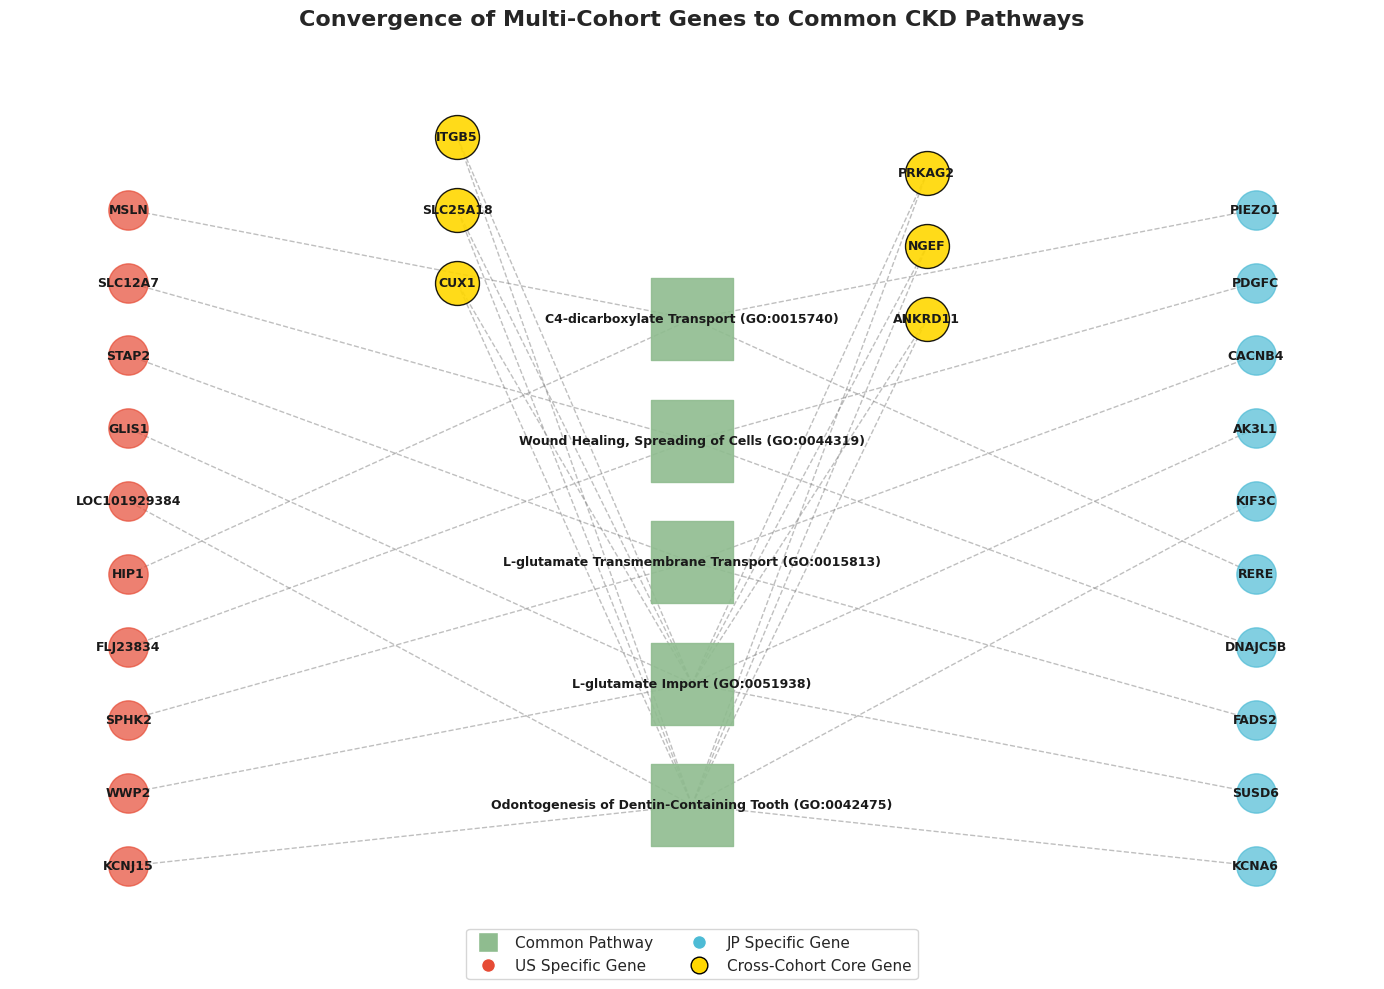

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

real_pathways = list(common_pathways)[:5]

# 取得各國特有基因 & 核心基因
us_only = list(set(us_ElasticNet_genes) - core_genes)[:10]
jp_only = list(set(jp_ElasticNet_genes) - core_genes)[:10]
core_nodes = list(core_genes)

G = nx.Graph()

# 新增節點
G.add_nodes_from(real_pathways, type='Pathway')
G.add_nodes_from(us_only, type='US_Gene')
G.add_nodes_from(jp_only, type='JP_Gene')
G.add_nodes_from(core_nodes, type='Core_Gene')

# 建立連線
for i, g in enumerate(us_only): G.add_edge(g, real_pathways[i % len(real_pathways)])
for i, g in enumerate(jp_only): G.add_edge(g, real_pathways[i % len(real_pathways)])
for g in core_nodes:
    for p in real_pathways[:2]: # 核心基因通常關聯多個路徑
        G.add_edge(g, p)

# 自訂座標佈局
pos = {}
# Pathway 在中央
for i, p in enumerate(real_pathways): pos[p] = (0, i - len(real_pathways)/2)
# US 基因在左側
for i, g in enumerate(us_only): pos[g] = (-1.2, (i - len(us_only)/2) * 0.6)
# JP 基因在右側
for i, g in enumerate(jp_only): pos[g] = (1.2, (i - len(jp_only)/2) * 0.6)
# Core 基因在中央上下方擴散
for i, g in enumerate(core_nodes): pos[g] = (0.5 if i%2==0 else -0.5, 1.5 + i*0.3)

# 繪圖
plt.figure(figsize=(14, 10))

# Pathway 綠色方塊
nx.draw_networkx_nodes(G, pos, nodelist=real_pathways, node_color='#8FBC8F', node_shape='s', node_size=3500, alpha=0.9)
# US 專有基因 紅
nx.draw_networkx_nodes(G, pos, nodelist=us_only, node_color='#E64B35', node_size=800, alpha=0.7)
# JP 專有基因 藍
nx.draw_networkx_nodes(G, pos, nodelist=jp_only, node_color='#4DBBD5', node_size=800, alpha=0.7)
# Core 跨國核心基因 金
nx.draw_networkx_nodes(G, pos, nodelist=core_nodes, node_color='#FFD700', node_size=1000, alpha=0.9, edgecolors='black')

nx.draw_networkx_edges(G, pos, edge_color='gray', style='dashed', alpha=0.5, width=1)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

plt.title('Convergence of Multi-Cohort Genes to Common CKD Pathways', fontsize=16, fontweight='bold', pad=25)
plt.axis('off')

# 增加圖例
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Common Pathway', markerfacecolor='#8FBC8F', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='US Specific Gene', markerfacecolor='#E64B35', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='JP Specific Gene', markerfacecolor='#4DBBD5', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Cross-Cohort Core Gene', markerfacecolor='#FFD700', markersize=12, markeredgecolor='black')
]
plt.legend(handles=legend_elements, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()


--- 繪製雙世代聯合熱圖 (Cross-Cohort Mega Heatmap) ---


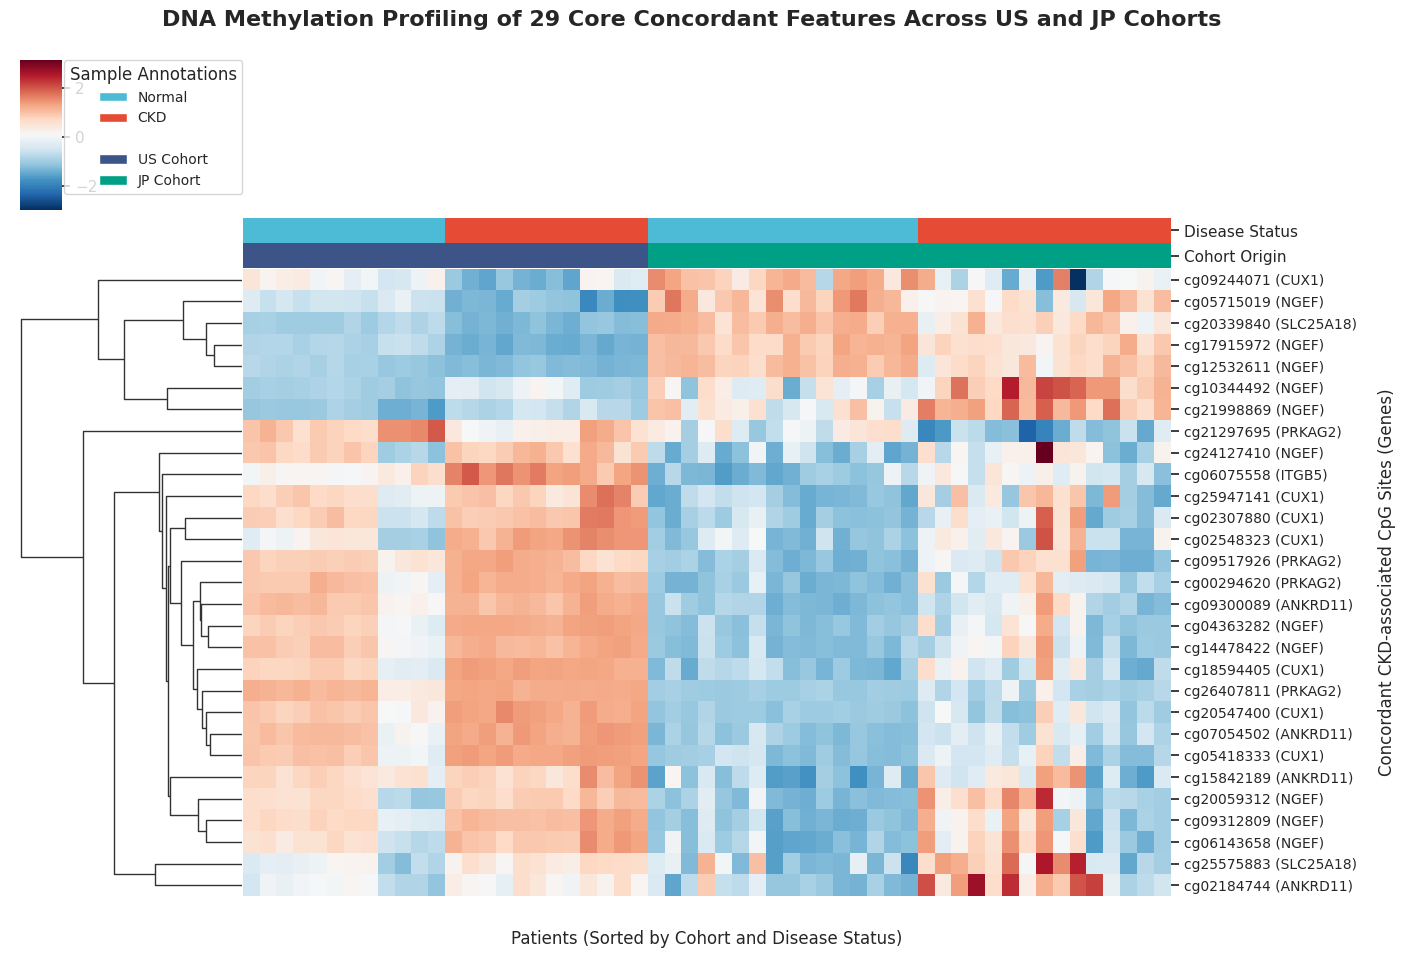

In [ ]:
from matplotlib.patches import Patch

print("\n--- 繪製雙世代聯合熱圖 (Cross-Cohort Mega Heatmap) ---")

# 準備合併資料 (結合 US 與 JP)
# us
X_us_plot = X_us_r[final_cpg_features].copy()
X_us_plot['Status'] = ['CKD' if val == 1 else 'Normal' for val in y_us]
X_us_plot['Cohort'] = 'US'

# jp
X_jp_plot = X_jp_r[final_cpg_features].copy()
X_jp_plot['Status'] = ['CKD' if val == 1 else 'Normal' for val in y_jp]
X_jp_plot['Cohort'] = 'JP'

# 合併成一張大表
plot_data_all = pd.concat([X_us_plot, X_jp_plot], axis=0)

# 排序樣本：先按 Cohort 排，再按 Status 排 (這會讓熱圖切分成完美的四個區塊)
plot_data_all = plot_data_all.sort_values(by=['Cohort', 'Status'], ascending=[False, False])

# 準備頂部雙層顏色標籤 (Column Colors)
status_pal = {'Normal': '#4DBBD5', 'CKD': '#E64B35'} # 藍色正常, 紅色疾病
cohort_pal = {'US': '#3C5488', 'JP': '#00A087'}      # 深藍美國, 墨綠日本

col_colors = pd.DataFrame({
    'Disease Status': plot_data_all['Status'].map(status_pal),
    'Cohort Origin': plot_data_all['Cohort'].map(cohort_pal)
})

# 準備 Y 軸基因標籤 (替換掉無意義的 cg 編號)
# 確保你前面有跑 summary，我們把 CpG ID 對應到 基因名稱
def get_display_name(cpg):
    # Use df_dmp_us to get the gene name for the CpG site
    if cpg in df_dmp_us.index:
        gene_raw = df_dmp_us.loc[cpg, 'N_to_C.gene']
        if pd.notna(gene_raw) and str(gene_raw) != 'nan':
            gene_clean = str(gene_raw).split(';')[0].strip()
            return f"{cpg} ({gene_clean})"
    return f"Intergenic ({cpg})"

# 將欄位名稱直接換成基因名稱
# 將 feats 替換為 final_cpg_features
plot_data_all_features = plot_data_all[final_cpg_features].rename(columns={c: get_display_name(c) for c in final_cpg_features})

# 繪製 Clustermap
g = sns.clustermap(
    plot_data_all_features.T,
    cmap='RdBu_r',             # 藍白紅漸層 (最經典的表觀遺傳配色)
    col_colors=col_colors,     # 頂部加入雙層標籤
    col_cluster=False,         # 關閉行聚類，保持我們設定的 US/JP 完美分界
    row_cluster=True,          # 開啟列聚類，讓行為相似的基因靠在一起
    z_score=0,                 # 🌟 關鍵：列方向的 Z-score 標準化，極大化紅藍對比
    figsize=(14, 10),          # 加大圖表尺寸
    cbar_pos=(0.02, 0.82, 0.03, 0.15), # 調整 Colorbar 位置
    tree_kws={'linewidths': 1.0},
    yticklabels=True           # 顯示我們做好的基因標籤
)

# 微調字體與標題
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize=10, rotation=0)
g.ax_heatmap.set_xticklabels([]) # 隱藏底部的 X 軸樣本名稱 (太多了沒意義)
g.ax_heatmap.set_xlabel('Patients (Sorted by Cohort and Disease Status)', fontsize=12, labelpad=15)
g.ax_heatmap.set_ylabel('Concordant CKD-associated CpG Sites (Genes)', fontsize=12, labelpad=15)

g.fig.suptitle('DNA Methylation Profiling of 29 Core Concordant Features Across US and JP Cohorts',
               y=1.02, fontsize=16, fontweight='bold')

# 手動添加圖例 (Legend)
handles = [
    Patch(facecolor=status_pal['Normal'], label='Normal'),
    Patch(facecolor=status_pal['CKD'], label='CKD'),
    Patch(facecolor='white', label=''), # 空白佔位符
    Patch(facecolor=cohort_pal['US'], label='US Cohort'),
    Patch(facecolor=cohort_pal['JP'], label='JP Cohort')
]
plt.legend(handles=handles, title='Sample Annotations', bbox_to_anchor=(1.05, 1),
           loc='upper left', borderaxespad=0., frameon=True, fontsize=10, title_fontsize=12)

plt.show()